## **모델 훈련 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch04 연습문제 1, 5, 9, 10
- 개념 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

### **1. 수백만 개의 특성을 가진 훈련 세트에서는 어떤 선형 회귀 알고리즘을 사용할 수 있을까요?**
___


- 확률적 경사 하강법(Stochastic Gradient Descent, SGD): 한 번에 하나의 샘플씩 사용하여 가중치를 업데이트하기 때문에 계산량이 적고 대규모 데이터에서도 효과적임.
- 미니배치 경사 하강법(Mini-batch Gradient Descent): 작은 배치 단위로 가중치를 업데이트하여 성능과 속도의 균형을 맞춤.

### **2. 배치 경사 하강법을 사용하고 에포크마다 검증 오차를 그래프로 나타내봤습니다. 검증 오차가 일정하게 상승되고 있다면 어떤 일이 일어나고 있는 걸까요? 이 문제를 어떻게 해결할 수 있나요?**
___

검증 오차가 지속적으로 상승하는 경우, 일반적으로 과적합이 발생하고 있다는 신호이다.
이를 해결하기 위해 아래 방법을 사용할 수 있음.

- 조기 종료(Early Stopping): 검증 오차가 다시 증가하기 시작하는 시점을 감지하고 학습을 중단하여 과적합을 방지함.
- 규제(Regularization) 적용: L1(라쏘 회귀) 또는 L2(릿지 회귀) 정규화를 적용하여 모델의 복잡도를 낮춤.
- 더 많은 데이터 사용: 데이터가 충분하지 않다면, 더 많은 훈련 데이터를 확보하거나 데이터 증강 기법을 활용할 수 있음.
- 학습률 조정: 학습률이 너무 크면 최적점에서 벗어나 과적합이 심화될 수 있으므로 적절한 학습률을 설정해야 함.

### **3. 릿지 회귀를 사용했을 때 훈련 오차가 검증 오차가 거의 비슷하고 둘 다 높았습니다. 이 모델에는 높은 편향이 문제인가요, 아니면 높은 분산이 문제인가요? 규제 하이퍼파라미터 $\alpha$를 증가시켜야 할까요 아니면 줄여야 할까요?**
___

- 훈련 오차와 검증 오차가 모두 높은 경우, 이는 높은 편향(high bias) 문제, 즉 과소적합(underfitting) 상태를 의미함.
- 릿지 회귀의 규제 하이퍼파라미터 𝛼를 증가시키면 가중치에 대한 패널티가 커지면서 모델이 더 단순해지므로, 𝛼를 줄여야 함.
- 즉, 𝛼를 감소시키면 모델이 데이터를 더 잘 학습할 수 있어 편향이 줄어들 가능성이 있음.

### **4. 다음과 같이 사용해야 하는 이유는?**

- 평범한 선형 회귀(즉, 아무런 규제가 없는 모델) 대신 릿지 회귀
- 릿지 회귀 대신 라쏘 회귀
- 라쏘 회귀 대신 엘라스틱넷
---

- 평범한 선형 회귀(즉, 아무런 규제가 없는 모델) 대신 릿지 회귀를 사용하는 이유
    - 릿지 회귀(Ridge Regression, L2 정규화) 는 과적합을 방지하고 모델의 가중치를 적절히 조절하여 일반화 성능을 높이는 역할을 함.
    - 선형 회귀는 노이즈가 있는 데이터에서 가중치가 매우 커질 위험이 있지만, 릿지 회귀는 이를 방지할 수 있음.

- 릿지 회귀 대신 라쏘 회귀를 사용하는 이유
    - 라쏘 회귀(Lasso Regression, L1 정규화) 는 가중치 중 일부를 0으로 만들어 변수 선택(Feature Selection) 기능을 수행함.
    - 불필요한 특성이 많을 경우, 라쏘 회귀를 사용하면 더 해석 가능한 모델을 만들 수 있음.

- 라쏘 회귀 대신 엘라스틱넷을 사용하는 이유
    - 엘라스틱넷(Elastic Net) 은 릿지와 라쏘의 결합 형태로, L1과 L2 정규화를 동시에 적용함.
    - 라쏘 회귀는 특성 개수가 많고 상관관계가 높은 경우 성능이 떨어질 수 있는데, 엘라스틱넷은 이를 보완할 수 있음.
    - 즉, 변수 선택 기능이 필요하면서도, 다중 공선성 문제가 있는 경우 엘라스틱넷이 좋은 선택.

### **추가) 조기 종료를 사용한 배치 경사 하강법으로 iris 데이터를 활용해 소프트맥스 회귀를 구현해보세요(사이킷런은 사용하지 마세요)**


---



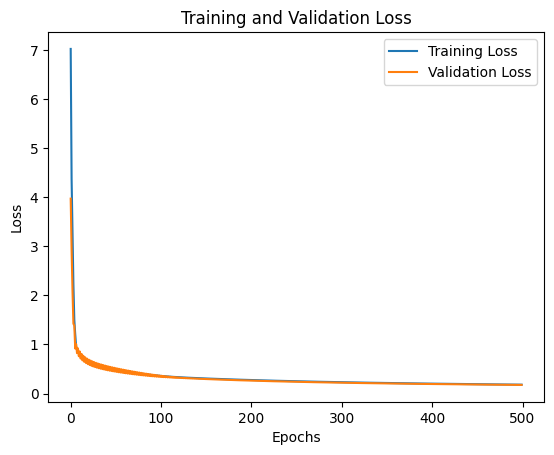

최종 학습된 가중치:
 [[ 0.66498978  1.57976477 -0.81002904]
 [ 1.42905508 -1.71081906 -1.99256905]
 [-2.53149022 -1.0502009   1.72915914]
 [-0.88157444 -0.3509162   1.73924535]]
최종 학습된 편향:
 [[ 0.33349584  0.49446598 -0.82796182]]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# 데이터 로드 및 전처리
iris = load_iris()
X = iris.data  # 특성 데이터 (꽃받침 길이, 너비, 꽃잎 길이, 너비)
y = iris.target.reshape(-1, 1)  # 타겟 데이터

# 타겟을 원-핫 인코딩 (sparse_output=False 사용)
encoder = OneHotEncoder(sparse_output=False)
y_one_hot = encoder.fit_transform(y)

# 훈련 세트와 검증 세트 분리
X_train, X_val, y_train, y_val = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# 소프트맥스 함수 정의
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # 오버플로 방지
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 손실 함수 (크로스 엔트로피) 정의
def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))  # 작은 값을 추가해 log 안정화

# 하이퍼파라미터 설정
learning_rate = 0.1
epochs = 500
early_stopping_rounds = 10  # 조기 종료 기준 (연속으로 검증 손실이 증가하면 중단)
batch_size = X_train.shape[0]  # 배치 경사 하강법 (전체 데이터 사용)
n_classes = y_train.shape[1]  # 클래스 개수 (3개)
n_features = X_train.shape[1]  # 특성 개수 (4개)

# 가중치 초기화
W = np.random.randn(n_features, n_classes)
b = np.zeros((1, n_classes))

# 학습 진행
best_val_loss = float('inf')
early_stopping_counter = 0
train_losses, val_losses = [], []

for epoch in range(epochs):
    # 선형 연산
    logits = np.dot(X_train, W) + b
    y_train_pred = softmax(logits)

    # 손실 계산
    train_loss = cross_entropy(y_train, y_train_pred)

    # 그래디언트 계산 (배치 경사 하강법)
    grad_W = np.dot(X_train.T, (y_train_pred - y_train)) / batch_size
    grad_b = np.sum(y_train_pred - y_train, axis=0, keepdims=True) / batch_size

    # 가중치 업데이트
    W -= learning_rate * grad_W
    b -= learning_rate * grad_b

    # 검증 데이터 평가
    val_logits = np.dot(X_val, W) + b
    y_val_pred = softmax(val_logits)
    val_loss = cross_entropy(y_val, y_val_pred)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # 조기 종료 조건 확인
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1

    if early_stopping_counter >= early_stopping_rounds:
        print(f"조기 종료 발생 (Epoch {epoch})")
        break

# 학습 과정 시각화
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# 최종 학습된 가중치 출력
print("최종 학습된 가중치:\n", W)
print("최종 학습된 편향:\n", b)